# Tarea 1 - Demographic Profile & Migration Landscape
**Team members**: [Renato Fernández] , [Vicente Vargas]

**Region**: [Región Metropolitana de Santiago (Maipú)]

**Date**: [03/26/2026]

## Part 0: Data Loading & Joins

### 0.1 Load the three Census tables

Primero vamos a ver todos los nombres de las columnas de cada archivo parquet de tal forma de saber si existe alguna incongruencia con las nombres solicitados en las instrucciones.

In [5]:
import pandas as pd

# Ver nombres de las columnas
vivienda = pd.read_parquet("viviendas_censo2024.parquet")
hogar = pd.read_parquet("hogares_censo2024.parquet")
persona = pd.read_parquet("personas_censo2024.parquet")

print("COLUMNAS VIVIENDA:")
print(vivienda.columns.tolist())

print("\nCOLUMNAS HOGAR:")
print(hogar.columns.tolist())

print("\nCOLUMNAS PERSONA:")
print(persona.columns.tolist())

COLUMNAS VIVIENDA:
['id_vivienda', 'region', 'provincia', 'comuna', 'comuna_bajo_umbral', 'area', 'tipo_operativo', 'cant_hog', 'cant_per', 'p2_tipo_vivienda', 'p3a_estado_ocupacion', 'p3b_estado_ocupacion', 'p4a_mat_paredes', 'p4b_mat_techo', 'p4c_mat_piso', 'p5_num_dormitorios', 'p6_fuente_agua', 'p7_distrib_agua', 'p8_serv_hig', 'p9_fuente_elect', 'p10_basura', 'p11a_num_personas', 'p11b_comparte_gasto', 'p11c_num_hogar', 'indice_hacinamiento']

COLUMNAS HOGAR:
['id_vivienda', 'id_hogar', 'region', 'provincia', 'comuna', 'comuna_bajo_umbral', 'area', 'tipo_operativo', 'p12_tenencia_viv', 'p13_comb_cocina', 'p14_comb_calefaccion', 'p15a_serv_tel_movil', 'p15b_serv_compu', 'p15c_serv_tablet', 'p15d_serv_internet_fija', 'p15e_serv_internet_movil', 'p15f_serv_internet_satelital', 'tipologia_hogar']

COLUMNAS PERSONA:
['id_vivienda', 'id_hogar', 'id_persona', 'region', 'provincia', 'comuna', 'comuna_bajo_umbral', 'area', 'tipo_operativo', 'sexo', 'edad', 'edad_quinquenal', 'parentesco', 

Al analizar los nombres de las columnas, nos dimos cuenta que para la tabla de viviendas, la columna "codigo_comuna" no existe y corresponde con la columna "comuna", además no existe una columna "materialidad", sino que esta dividido en 3 columnas diferentes. Con esto en mente concluimos que el mejor curso de acción es renombrarlas. Cabe recalcar que nos percatamos que la columna "hacinamiento" que debería estar en la tabla hogar, en realidad está en la tabla vivienda, con lo cual se procederá a trabajar con la columna hacinamiento en esta tabla. Otro detalle es que una vez más se cambio el nombre de la columna "p12_tenencia_viv" a "tenencia" por congruencia con la tarea.

In [7]:
# Vivienda
vivienda = pd.read_parquet(
    "viviendas_censo2024.parquet",
    columns=[
        "id_vivienda",
        "region",
        "comuna",
        "indice_hacinamiento",
        "p4a_mat_paredes",
        "p4b_mat_techo",
        "p4c_mat_piso"
    ]
).rename(columns={
    "comuna": "codigo_comuna",
    "indice_hacinamiento": "hacinamiento",
    "p4a_mat_paredes": "materialidad_paredes",
    "p4b_mat_techo": "materialidad_techo",
    "p4c_mat_piso": "materialidad_piso"
})

# Hogar
hogar = pd.read_parquet(
    "hogares_censo2024.parquet",
    columns=[
        "id_vivienda",
        "id_hogar",
        "p12_tenencia_viv"
    ]
).rename(columns={
    "p12_tenencia_viv": "tenencia"
})

# Persona
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=[
        "id_vivienda",
        "id_hogar",
        "id_persona",
        "sexo",
        "edad",
        "p27_nacionalidad_esp",
        "p25_lug_nacimiento_rec",
        "p24_lug_resid5",
        "p25_lug_nacimiento",
        "p26_llegada_periodo",
        "escolaridad",
        "cine11",
        "sit_fuerza_trabajo",
        "cod_ciuo",
        "cod_caenes",
        "p45_medio_transporte"
    ]
)

print("COLUMNAS VIVIENDA:")
print(vivienda.columns.tolist())

print("\nCOLUMNAS HOGAR:")
print(hogar.columns.tolist())

print("\nCOLUMNAS PERSONA:")
print(persona.columns.tolist())

COLUMNAS VIVIENDA:
['id_vivienda', 'region', 'codigo_comuna', 'hacinamiento', 'materialidad_paredes', 'materialidad_techo', 'materialidad_piso']

COLUMNAS HOGAR:
['id_vivienda', 'id_hogar', 'tenencia']

COLUMNAS PERSONA:
['id_vivienda', 'id_hogar', 'id_persona', 'sexo', 'edad', 'p27_nacionalidad_esp', 'p25_lug_nacimiento_rec', 'p24_lug_resid5', 'p25_lug_nacimiento', 'p26_llegada_periodo', 'escolaridad', 'cine11', 'sit_fuerza_trabajo', 'cod_ciuo', 'cod_caenes', 'p45_medio_transporte']


Además, debido a que "nombre_comuna" no se encuentra denominado, procederemos a también incluir el dataset diccionario_variables_censo2024.csv. Sin embargo contaremos a partir del 998 al 16305 con tal de evitar los códigos pertenecientes a países y los códigos como 1000,2000,3000,..., que corresponden a nombres de regiones.

In [9]:
# Load dictionary
diccionario = pd.read_excel(
    "diccionario_variables_censo2024.xlsx",
    sheet_name="cod_territoriales_especificos",
    engine="openpyxl"
)

# Mantener solo comunas
mapa_comunas = diccionario[
    (diccionario["Código específico"] >= 998) &
    (diccionario["Código específico"] <= 16305) &
    (diccionario["Código específico"] % 1000 != 0)
][[
    "Código específico",
    "Territorio específico"
]].drop_duplicates()

# Renombrar para hacer match con vivienda
mapa_comunas = mapa_comunas.rename(columns={
    "Código específico": "codigo_comuna",
    "Territorio específico": "nombre_comuna"
})

# Asegurar mismo tipo de dato
vivienda["codigo_comuna"] = vivienda["codigo_comuna"].astype(int)
mapa_comunas["codigo_comuna"] = mapa_comunas["codigo_comuna"].astype(int)

# Merge con vivienda
vivienda = vivienda.merge(
    mapa_comunas,
    on="codigo_comuna",
    how="left"
)

# Verificación
print(vivienda.columns.tolist())
vivienda[["codigo_comuna", "nombre_comuna"]].drop_duplicates().head(10)

['id_vivienda', 'region', 'codigo_comuna', 'hacinamiento', 'materialidad_paredes', 'materialidad_techo', 'materialidad_piso', 'nombre_comuna']


,codigo_comuna,nombre_comuna
0,5802,Limache
1,4303,Monte Patria
2,11202,Cisnes
3,1101,Iquique
4,8301,Los Ángeles
5,13124,Pudahuel
6,8111,Tomé
7,14108,Panguipulli
8,13101,Santiago
9,16207,Trehuaco


### 0.2 Filter to your comunas

Luego de buscar en el archivo excel diccionario_variables_censo2024, encontramos que la comuna de Maipú se encontraba denominada bajo el código 13119. Sin embargo, por mayor comodidad e intuición preferimos realizar la búsqueda por nombre.

In [12]:
# Comuna asignada
MY_COMUNAS = ["Maipú"]

# Normalizar en caso de diferencias de espacios y/o de minusculas/mayusculas
vivienda["nombre_comuna"] = vivienda["nombre_comuna"].str.strip().str.lower()

MY_COMUNAS = [c.strip().lower() for c in MY_COMUNAS]

# Filter vivienda
viv = vivienda[vivienda["nombre_comuna"].isin(MY_COMUNAS)]

# Filter hogar
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])]

# Filter persona
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])]

# Reportar número de rows
print("Rows vivienda:", len(viv))
print("Rows hogar:", len(hog))
print("Rows persona:", len(per))

Rows vivienda: 169599
Rows hogar: 167650
Rows persona: 503635


### 0.3 Join the tables

In [14]:
# Join persona + hogar + vivienda
df = per.merge(
    hog,
    on=["id_vivienda", "id_hogar"],
    how="left"
).merge(
    viv,
    on="id_vivienda",
    how="left"
)

# Reporte
print("Shape:", df.shape)
df.info()

Shape: (503635, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503635 entries, 0 to 503634
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             503635 non-null  int32  
 1   id_hogar                503635 non-null  int32  
 2   id_persona              503635 non-null  int32  
 3   sexo                    503635 non-null  int32  
 4   edad                    503635 non-null  int32  
 5   p27_nacionalidad_esp    503635 non-null  int32  
 6   p25_lug_nacimiento_rec  503635 non-null  int32  
 7   p24_lug_resid5          503635 non-null  int32  
 8   p25_lug_nacimiento      503635 non-null  int32  
 9   p26_llegada_periodo     30973 non-null   float64
 10  escolaridad             503635 non-null  int32  
 11  cine11                  503635 non-null  int32  
 12  sit_fuerza_trabajo      422663 non-null  float64
 13  cod_ciuo                235414 non-null  float64
 14  

## Part 1: Demographic Profile

### 1.1 Age pyramid by sex

Primero vamos a mostrar bajo que valores se representan el sexo y la nacionalidad.

In [18]:
print(df["sexo"].value_counts(dropna=False).sort_index())
print(df["p25_lug_nacimiento_rec"].value_counts(dropna=False).sort_index())

sexo
1    240903
2    262732
Name: count, dtype: int64
p25_lug_nacimiento_rec
-99      3035
 1     469627
 2      30973
Name: count, dtype: int64


Luego de examinar los resultados, buscamos en el diccionario y descubrimos que en sexo 1: Hombre y 2: Mujer. Mientras que para p25_lug_nacimiento_rec, los resultados responden a la pregunta ¿Nació en Chile?, en la cual 1: Sí, 2: No y -99: No respuesta.

C:\Users\renat\AppData\Local\Temp\ipykernel_12148\1654666788.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_group", "sexo", "p25_lug_nacimiento_rec"])


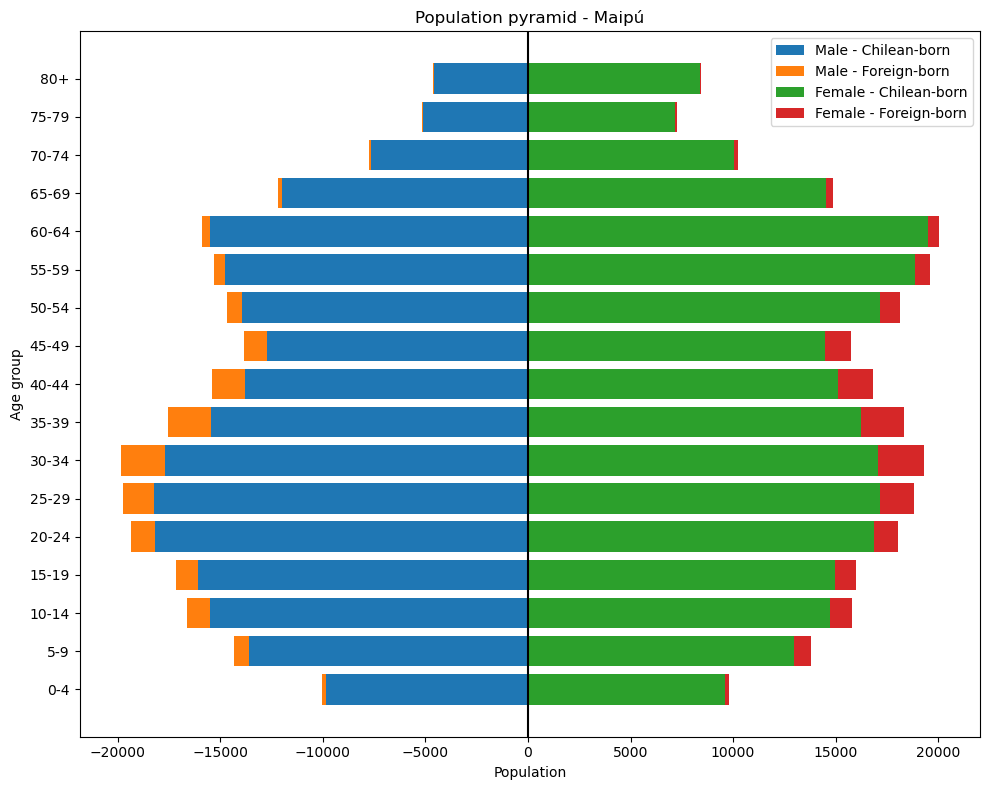

In [20]:
import matplotlib.pyplot as plt
import numpy as np

piramide = df.copy()

# Quitar info faltante
piramide = piramide[
    (piramide["edad"] != -66) &
    (piramide["p25_lug_nacimiento_rec"] != -99)
].copy()

# Crear grupos de edad
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]

piramide["age_group"] = pd.cut(
    piramide["edad"],
    bins=bins,
    labels=labels,
    right=False
)

# Sexo
male_code = 1
female_code = 2

# ¿Nació en Chile?
chile_born_code = 1
foreign_born_code = 2

# Contar populación por age, sexo y lugar de nacimiento
grouped = (
    piramide
    .groupby(["age_group", "sexo", "p25_lug_nacimiento_rec"])
    .size()
    .reset_index(name="count")
)

# Male - Chilean-born
male_chilean = (
    grouped[
        (grouped["sexo"] == male_code) &
        (grouped["p25_lug_nacimiento_rec"] == chile_born_code)
    ]
    .set_index("age_group")["count"]
    .reindex(labels, fill_value=0)
)

# Male - Foreign-born
male_foreign = (
    grouped[
        (grouped["sexo"] == male_code) &
        (grouped["p25_lug_nacimiento_rec"] == foreign_born_code)
    ]
    .set_index("age_group")["count"]
    .reindex(labels, fill_value=0)
)

# Female - Chilean-born
female_chilean = (
    grouped[
        (grouped["sexo"] == female_code) &
        (grouped["p25_lug_nacimiento_rec"] == chile_born_code)
    ]
    .set_index("age_group")["count"]
    .reindex(labels, fill_value=0)
)

# Female - Foreign-born
female_foreign = (
    grouped[
        (grouped["sexo"] == female_code) &
        (grouped["p25_lug_nacimiento_rec"] == foreign_born_code)
    ]
    .set_index("age_group")["count"]
    .reindex(labels, fill_value=0)
)

# Plot pyramid
y = np.arange(len(labels))

plt.figure(figsize=(10, 8))

plt.barh(
    y,
    -male_chilean.values,
    label="Male - Chilean-born"
)

plt.barh(
    y,
    -male_foreign.values,
    left=-male_chilean.values,
    label="Male - Foreign-born"
)

plt.barh(
    y,
    female_chilean.values,
    label="Female - Chilean-born"
)

plt.barh(
    y,
    female_foreign.values,
    left=female_chilean.values,
    label="Female - Foreign-born"
)

plt.yticks(y, labels)
plt.axvline(0, color="black")
plt.xlabel("Population")
plt.ylabel("Age group")
plt.title("Population pyramid - Maipú")
plt.legend()
plt.tight_layout()
plt.show()

La pirámide poblacional de Maipú muestra que una gran parte de la población se concentra en edades laborales, especialmente entre los 20 y 39 años. En las personas nacidas en Chile, la distribución se reparte de forma más amplia entre los distintos grupos de edad, incluyendo una mayor presencia en edades más avanzadas. En cambio, la población nacida en el extranjero se concentra mucho más en edades jóvenes-adultas, y se observa que no hay muchos casos en edades mayores. También se aprecia una distribución bastante equilibrada entre hombres y mujeres, aunque en los tramos más altos parece haber una presencia algo mayor de mujeres, sugiriendo una expectativa de vida mayor para las mujeres. En general, el gráfico sugiere que la migración en Maipú está compuesta sobre todo por personas en edad de trabajar, y menos por población de edades extremas como niños pequeños o adultos mayores.

### 1.2 Dependency ratio

In [23]:
# Filtrar edades válidas
dep = df[df["edad"] != -66].copy()

# Clasificar grupos etarios
dep["grupo"] = pd.cut(
    dep["edad"],
    bins=[0, 15, 65, 200],
    labels=["0-14", "15-64", "65+"],
    right=False
)

# Conteo por comuna y grupo
tabla = (
    dep
    .groupby(["nombre_comuna", "grupo"])
    .size()
    .unstack(fill_value=0)
)

# Calcular dependency ratio
tabla["dependency_ratio"] = (
    (tabla["0-14"] + tabla["65+"]) / tabla["15-64"]
)

# Resultado
tabla[["dependency_ratio"]]

C:\Users\renat\AppData\Local\Temp\ipykernel_12148\4283276437.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["nombre_comuna", "grupo"])


grupo,dependency_ratio
nombre_comuna,
maipú,0.43267


La comuna de Maipú presenta un dependency_ratio de 0,4327, lo que indica que hay alrededor de 43 personas dependientes por cada 100 personas en edad de trabajar. Este resultado va en línea con lo que esperábamos, ya que sugiere que el peso de la población en edad de trabajar es mayor que el de la población dependiente. En otras palabras, aunque sí hay presencia de niños y adultos mayores, su proporción es menor en comparación con el grupo de 15 a 64 años.

### 1.3 Household size distribution 

En este caso necesitamos la columna p27_nacionalidad_rec que nos dice claramente si la persona tiene nacionalidad chilena, en la cual 1: Sí, 2: No y -99: No respuesta.

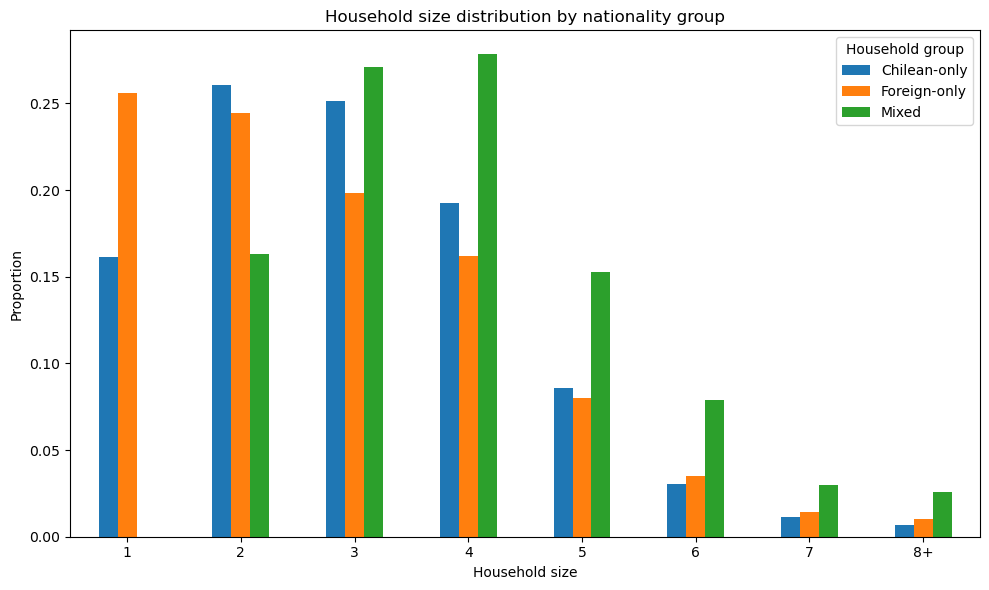

In [27]:
# Reincorporar p27_nacionalidad_rec a df
if "p27_nacionalidad_rec" not in df.columns:
    persona_extra = pd.read_parquet(
        "personas_censo2024.parquet",
        columns=[
            "id_vivienda",
            "id_hogar",
            "id_persona",
            "p27_nacionalidad_rec"
        ]
    )

    df = df.merge(
        persona_extra,
        on=["id_vivienda", "id_hogar", "id_persona"],
        how="left"
    )

# Mantener valores válidos
hogares_dist = df[df["p27_nacionalidad_rec"] != -99].copy()

# Personas por hogar
hogares_resumen = (
    hogares_dist
    .groupby(["id_vivienda", "id_hogar"])
    .agg(
        household_size=("id_persona", "count"),
        n_chilean=("p27_nacionalidad_rec", lambda x: (x == 1).sum()),
        n_foreign=("p27_nacionalidad_rec", lambda x: (x == 2).sum())
    )
    .reset_index()
)

# Clasificación del hogar
def classify_household(row):
    if row["n_chilean"] > 0 and row["n_foreign"] == 0:
        return "Chilean-only"
    elif row["n_foreign"] > 0 and row["n_chilean"] == 0:
        return "Foreign-only"
    else:
        return "Mixed"

hogares_resumen["household_group"] = hogares_resumen.apply(classify_household, axis=1)

# Crear categoría 8+
hogares_resumen["household_size_cat"] = hogares_resumen["household_size"].apply(
    lambda x: str(x) if x < 8 else "8+"
)

orden = [str(i) for i in range(1, 8)] + ["8+"]

# Tabla de distribución
dist_tabla = (
    hogares_resumen
    .groupby(["household_size_cat", "household_group"])
    .size()
    .unstack(fill_value=0)
    .reindex(orden, fill_value=0)
)

# Proporciones
dist_prop = dist_tabla.div(dist_tabla.sum(axis=0), axis=1)

# Gráfico
dist_prop.plot(kind="bar", figsize=(10, 6))

plt.title("Household size distribution by nationality group")
plt.xlabel("Household size")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Household group")
plt.tight_layout()
plt.show()

*Chilean-only:* Todos los miembros del hogar tienen nacionalidad chilena.\
*Foreign-only:* Todos los miembros del hogar no tienen nacionalidad chilena.\
*Mixed:* Conviven miembros chilenos y extranjeros en el hogar.

Sí se observan diferencias entre los grupos. En los hogares foreign-only se ve una mayor concentración en tamaños pequeños, especialmente de 1 y 2 integrantes. En los hogares Chilean-only, la mayor parte se concentra en tamaños intermedios, sobre todo de 2 y 3 personas. En cambio, los hogares mixed tienden a ser más grandes, ya que tienen una mayor presencia en tamaños de 3, 4 y 5 integrantes, e incluso siguen apareciendo con más frecuencia en tamaños altos. En general, el gráfico sugiere que los hogares mixtos suelen ser más numerosos, mientras que los hogares formados solo por personas sin nacionalidad chilena tienden a ser más pequeños.

### 1.4 Education and employment

Una vez más visualizamos las categorías que componen a la situación en la fuerza de trabajo en el diccionario, en la cual 1: Ocupado, 2: Desocupado, 3: Fuera de la fuerza de trabajo, -99: No respuesta y NA: No aplica.

In [32]:
print(df["sit_fuerza_trabajo"].value_counts(dropna=False).sort_index())

sit_fuerza_trabajo
-99.0      2334
 1.0     235414
 2.0      23987
 3.0     160928
 NaN      80972
Name: count, dtype: int64


En este apartado se comparan los años promedio de escolaridad y la tasa de empleo entre la población nacida en Chile y la población nacida en el extranjero que vive en la comuna de Maipú. Para hacer esta distinción se utiliza la variable p25_lug_nacimiento_rec, que permite separar ambos grupos según su lugar de nacimiento.

En el caso de la escolaridad, se consideran solo personas de 25 años o más, ya que a esa edad se espera que las personas ya hayan terminado sus estudios o que los tengan muy avanzados.

Por otro lado, para el análisis del empleo se considera a la población entre 15 y 64 años, debido a que ese tramo corresponde, de manera general, a la población en edad de trabajar.

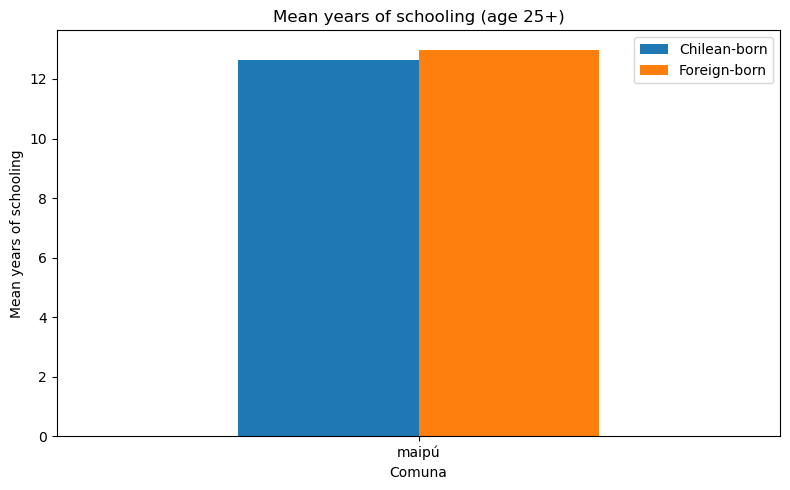

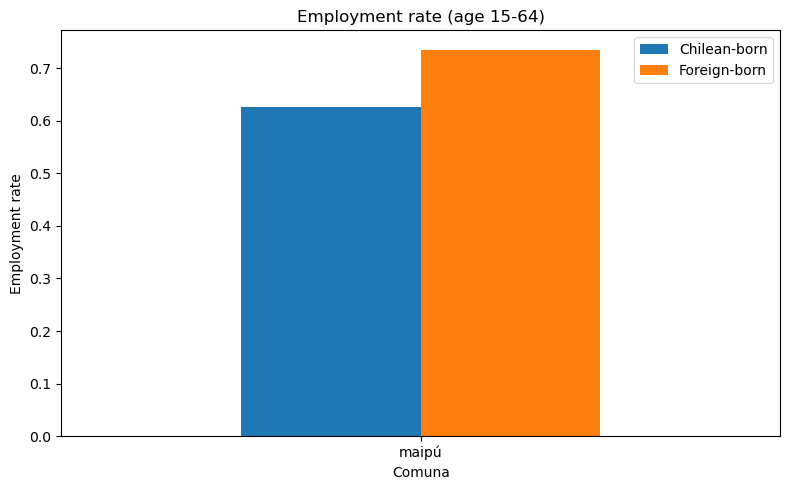

Schooling summary
  nombre_comuna  p25_lug_nacimiento_rec  escolaridad         group
0         maipú                       1    12.643312  Chilean-born
1         maipú                       2    12.984891  Foreign-born

Employment summary
  nombre_comuna  p25_lug_nacimiento_rec  employed         group
0         maipú                       1  0.625473  Chilean-born
1         maipú                       2  0.735107  Foreign-born


In [34]:
# Copiar base
edu_emp = df.copy()

# Filtrar valores válidos
edu_emp = edu_emp[
    (edu_emp["p25_lug_nacimiento_rec"] != -99) &
    (edu_emp["edad"] != -66)
].copy()

# Definir códigos
chilean_code = 1
foreign_code = 2

# Filtrar escolaridad 25+
schooling = edu_emp[
    (edu_emp["edad"] >= 25) &
    (edu_emp["escolaridad"] != -99)
].copy()

# Calcular promedio de escolaridad
schooling_summary = (
    schooling
    .groupby(["nombre_comuna", "p25_lug_nacimiento_rec"])["escolaridad"]
    .mean()
    .reset_index()
)

# Etiquetar grupos
schooling_summary["group"] = schooling_summary["p25_lug_nacimiento_rec"].map({
    chilean_code: "Chilean-born",
    foreign_code: "Foreign-born"
})

# Preparar datos para gráfico
schooling_plot = schooling_summary.pivot(
    index="nombre_comuna",
    columns="group",
    values="escolaridad"
)

# Filtrar empleo 15-64
employment = edu_emp[
    (edu_emp["edad"] >= 15) &
    (edu_emp["edad"] <= 64) &
    (edu_emp["sit_fuerza_trabajo"] != -99) &
    (edu_emp["sit_fuerza_trabajo"].notna())
].copy()

# Definir código de ocupado
employed_code = 1

# Crear variable de empleo
employment["employed"] = (
    employment["sit_fuerza_trabajo"] == employed_code
).astype(int)

# Calcular tasa de empleo
employment_summary = (
    employment
    .groupby(["nombre_comuna", "p25_lug_nacimiento_rec"])["employed"]
    .mean()
    .reset_index()
)

# Etiquetar grupos
employment_summary["group"] = employment_summary["p25_lug_nacimiento_rec"].map({
    chilean_code: "Chilean-born",
    foreign_code: "Foreign-born"
})

# Preparar datos para gráfico
employment_plot = employment_summary.pivot(
    index="nombre_comuna",
    columns="group",
    values="employed"
)

# Graficar escolaridad
ax = schooling_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Mean years of schooling (age 25+)")
plt.xlabel("Comuna")
plt.ylabel("Mean years of schooling")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

# Graficar empleo
ax = employment_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Employment rate (age 15-64)")
plt.xlabel("Comuna")
plt.ylabel("Employment rate")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

# Mostrar tablas
print("Schooling summary")
print(schooling_summary)

print("\nEmployment summary")
print(employment_summary)

En cuanto a la escolaridad, se observa que la población nacida en el extranjero tiene un promedio de años de estudio levemente superior al de la población nacida en Chile. De todos modos, la diferencia no es muy grande, por lo que en general ambos grupos muestran niveles relativamente similares en este aspecto.

En el caso del empleo, la diferencia se nota un poco más. La población nacida en el extranjero presenta una tasa de ocupación mayor que la población nacida en Chile dentro del tramo de 15 a 64 años. Esto sugiere que, al menos en esta comuna, las personas nacidas en el extranjero tienen una presencia relativamente más alta dentro de la población ocupada.

En conjunto, los resultados muestran que la población nacida en el extranjero que vive en Maipú no solo tiene un nivel de escolaridad muy parecido, e incluso un poco más alto, sino que además presenta una mayor tasa de empleo que la población nacida en Chile. En ese sentido, las diferencias más claras entre ambos grupos parecen darse en la participación laboral más que en la escolaridad.

## Part 2: Migration Landscape

### 2.1 Percentage foreign-born by comuna 

En este apartado se busca identificar qué proporción de la población que vive en cada comuna seleccionada nació fuera de Chile. Para esto, volveremos a utilizar la variable p25_lug_nacimiento_rec, ya que permite distinguir entre personas nacidas en Chile y personas nacidas en el extranjero. Además, se excluyen los casos con valor -99, ya que corresponden a respuestas no válidas. A partir de esto, la información se agrupa por comuna y se calcula el porcentaje de población nacida en el extranjero sobre el total de personas con dato válido. Con este resultado, se puede observar qué peso tiene este grupo dentro de la comuna analizada.

  nombre_comuna  pop_total  pop_foreign_born  pct_foreign_born
0         maipú     500600             30973          6.187175


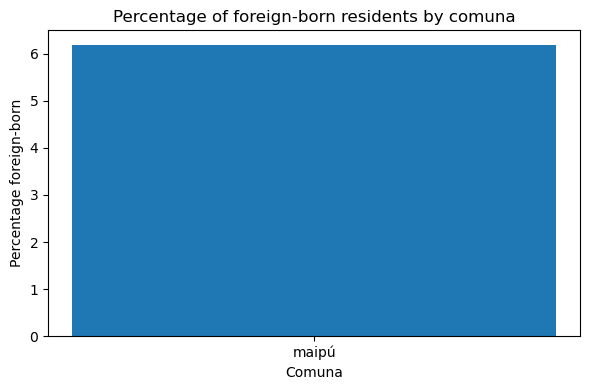

In [39]:
# Mantener valores válidos
foreign_share = df[df["p25_lug_nacimiento_rec"] != -99].copy()

# Resumen por comuna
tabla_foreign = (
    foreign_share
    .groupby("nombre_comuna")
    .agg(
        pop_total=("id_persona", "count"),
        pop_foreign_born=("p25_lug_nacimiento_rec", lambda x: (x == 2).sum())
    )
    .reset_index()
)

# Calcular porcentaje
tabla_foreign["pct_foreign_born"] = (
    tabla_foreign["pop_foreign_born"] / tabla_foreign["pop_total"] * 100
)

# Mostrar tabla
print(tabla_foreign)

# Graficar barras
plt.figure(figsize=(6, 4))
plt.bar(tabla_foreign["nombre_comuna"], tabla_foreign["pct_foreign_born"])
plt.title("Percentage of foreign-born residents by comuna")
plt.xlabel("Comuna")
plt.ylabel("Percentage foreign-born")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La comuna de Maipú presenta un porcentaje de población nacida en el extranjero cercano al 6,2%. Esto muestra que la mayoría de las personas que viven en la comuna nació en Chile, aunque igual hay una presencia importante de personas nacidas fuera del país. En ese sentido, se puede decir que la migración está presente en Maipú, pero no representa una parte mayoritaria de la población.

### 2.2 Top nationalities

Si bien las instrucciones piden utilizar la columna p27_nacionalidad, esta no es la indicada para saber cúales son las nacionalidades específicas de los extranjeros presentes en la base de datos, ya que esta columna solamente señala si las personas tienen nacionalidad 1: Chilena (exclusivamente), 2: Chilena y otra (doble nacionalidad), 3: Otra nacionalidad y -99: No respuesta. Con lo cual, a nosotros solamente nos interesa las personas categorizadas con 3 en la columna de p27_nacionalidad, ya que nos interesa saber la nacionalidad exclusivamente de extranjeros. Para lograr esto aislaremos a estas personas y además lo complementaremos con la columna p27_nacionalidad_esp en la que se denominan de manera específica las nacionalidades a las que pertenecen las personas en un rango de 2:862, según el diccionario.

In [43]:
# Reload persona con p27_nacionalidad incluida
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=[
        "id_vivienda",
        "id_hogar",
        "id_persona",
        "sexo",
        "edad",
        "p27_nacionalidad",
        "p27_nacionalidad_esp",
        "p25_lug_nacimiento_rec",
        "p24_lug_resid5",
        "p25_lug_nacimiento",
        "p26_llegada_periodo",
        "escolaridad",
        "cine11",
        "sit_fuerza_trabajo",
        "cod_ciuo",
        "cod_caenes",
        "p45_medio_transporte"
    ]
)

# Refilter persona using viviendas already filtered
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])].copy()

# Rebuild joined dataset
df = per.merge(
    hog,
    on=["id_vivienda", "id_hogar"],
    how="left"
).merge(
    viv,
    on="id_vivienda",
    how="left"
)

# Verify
print(df.shape)
print("p27_nacionalidad_esp" in df.columns)

(503635, 25)
True


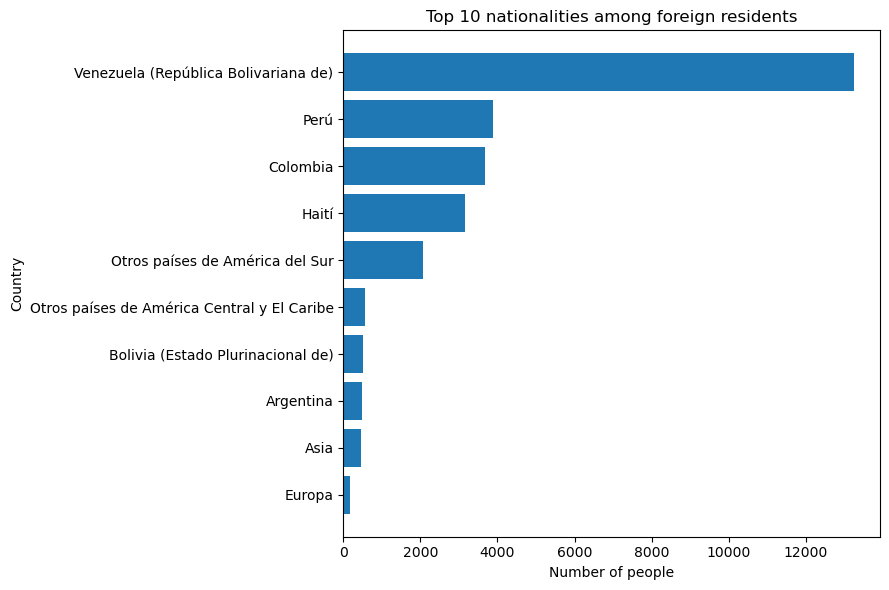

nombre_pais
Europa                                           181
Asia                                             449
Argentina                                        487
Bolivia (Estado Plurinacional de)                514
Otros países de América Central y El Caribe      560
Otros países de América del Sur                 2079
Haití                                           3150
Colombia                                        3678
Perú                                            3874
Venezuela (República Bolivariana de)           13261
Name: count, dtype: int64

In [44]:
# Cargar diccionario
dic_territorios = pd.read_excel(
    "diccionario_variables_censo2024.xlsx",
    sheet_name="cod_territoriales_especificos",
    engine="openpyxl"
)

# Filtrar códigos de países
mapa_paises = dic_territorios[
    (dic_territorios["Código específico"] >= 2) &
    (dic_territorios["Código específico"] <= 862)
][["Código específico", "Territorio específico"]].drop_duplicates()

# Renombrar columnas
mapa_paises = mapa_paises.rename(columns={
    "Código específico": "p27_nacionalidad_esp",
    "Territorio específico": "nombre_pais"
})

# Filtrar casos válidos
top_nat = df[
    (df["p27_nacionalidad"] == 3) &
    (df["p27_nacionalidad_esp"] != -99) &
    (df["p27_nacionalidad_esp"] != -66)
].copy()

# Unir nombres de país
top_nat = top_nat.merge(
    mapa_paises,
    on="p27_nacionalidad_esp",
    how="left"
)

# Contar top 10
top10_paises = (
    top_nat["nombre_pais"]
    .value_counts()
    .head(10)
    .sort_values()
)

# Graficar
plt.figure(figsize=(9, 6))
plt.barh(top10_paises.index, top10_paises.values)
plt.title("Top 10 nationalities among foreign residents")
plt.xlabel("Number of people")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Mostrar tabla
top10_paises

En este gráfico se ve que la nacionalidad con mayor presencia en Maipú es la venezolana, y además con bastante diferencia frente a las demás. Después aparecen Perú, Colombia y Haití, pero en cantidades bastante menores. En general, esto muestra que dentro de la población extranjera que vive en la comuna hay algunas nacionalidades que tienen mucha más presencia que otras.

### 2.3 Migration status: residence 5 years ago 

En este inciso tendremos que recurrir también a p24_lug_resid5_esp, ya que p24_lug_resid5 solamente nos ayuda a responder ¿En qué comuna o país vivía en abril de 2019? , en la cual 2: En esta comuna o 4: En otro país. Sin embargo no nos da información suficiente para saber si vivía en una comuna diferente, misma región o diferente región. Con lo cual para saber esto haremos uso de p24_lug_resid5_esp, la cual nos especifica el lugar específico en que vivía la persona hace 5 años, y con esta información podemos contrastar que en los códigos se repite un patrón en el cual 1000, 2000, 3000,..., 16000, donde cada comuna que pertenece a la misma región tiene ese/esos primer/primeros dígito/dígitos repetido/repetidos. Por ejemplo si actualmente la persona vive en la comuna 12043 y hace 5 años en 12005, eso quiere decir que siempre vivío en la región 12. Sin embargo si se tiene la comuna 3024 y 4032 entonces vive en una región diferente ahora, ya que antes vivía en la región 3 y ahora en la 4.

In [48]:
persona_extra = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=[
        "id_vivienda",
        "id_hogar",
        "id_persona",
        "p24_lug_resid5_esp"
    ]
)

df = df.merge(
    persona_extra,
    on=["id_vivienda", "id_hogar", "id_persona"],
    how="left"
)

print("p24_lug_resid5_esp" in df.columns)
df[["id_vivienda", "id_hogar", "id_persona", "p24_lug_resid5", "p24_lug_resid5_esp"]].head()

True


,id_vivienda,id_hogar,id_persona,p24_lug_resid5,p24_lug_resid5_esp
0,25,1,1,2,13119.0
1,25,1,2,2,13119.0
2,102,1,1,2,13119.0
3,196,1,1,2,13119.0
4,196,1,2,2,13119.0


mig_status_5y  Same comuna  Different comuna, same region  Different region  \
nombre_comuna                                                                 
maipú                 87.2                           9.15               1.6   

mig_status_5y  Abroad  
nombre_comuna          
maipú            2.05  


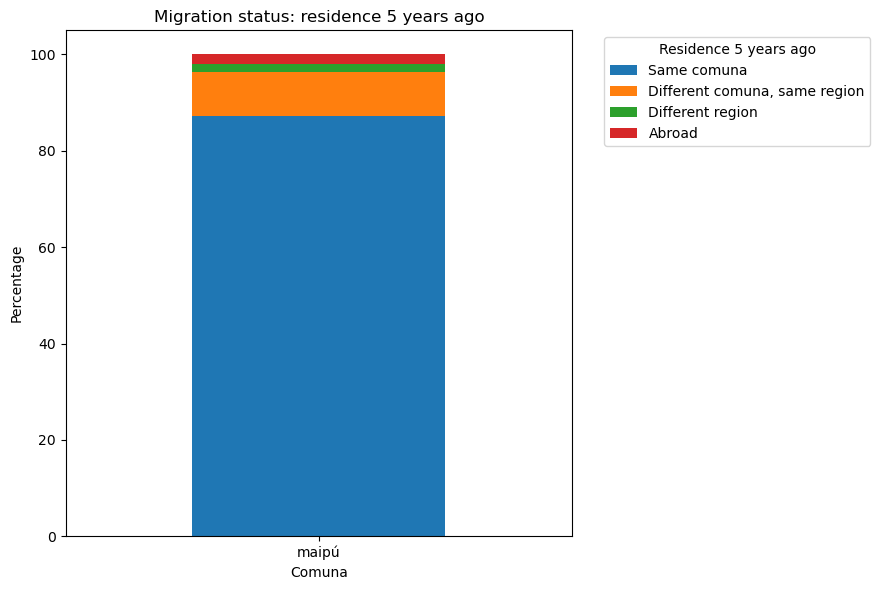

In [49]:
# Filtrar casos válidos
mig5 = df[
    (df["edad"] >= 5) &
    (df["edad"] != -99) &
    (df["p24_lug_resid5"] != -99)
].copy()

# Función para obtener la base regional
def region_base(code):
    return (int(code) // 1000) * 1000

# Clasificar situación migratoria
def classify_resid5(row):
    if row["p24_lug_resid5"] == 2:
        return "Same comuna"
    
    if row["p24_lug_resid5"] == 4:
        return "Abroad"
    
    if pd.isna(row["p24_lug_resid5_esp"]) or row["p24_lug_resid5_esp"] == -99:
        return np.nan
    
    comuna_actual = int(row["codigo_comuna"])
    comuna_pasada = int(row["p24_lug_resid5_esp"])
    
    if comuna_pasada == comuna_actual:
        return "Same comuna"
    
    if region_base(comuna_actual) == region_base(comuna_pasada):
        return "Different comuna, same region"
    
    return "Different region"

mig5["mig_status_5y"] = mig5.apply(classify_resid5, axis=1)

# Eliminar clasificaciones vacías
mig5 = mig5.dropna(subset=["mig_status_5y"]).copy()

# Tabla de porcentajes por comuna
tabla_mig5 = (
    mig5
    .groupby(["nombre_comuna", "mig_status_5y"])
    .size()
    .unstack(fill_value=0)
)

# Orden de columnas
orden_cols = [
    "Same comuna",
    "Different comuna, same region",
    "Different region",
    "Abroad"
]

tabla_mig5 = tabla_mig5.reindex(columns=orden_cols, fill_value=0)

# Convertir a porcentajes
tabla_mig5_pct = tabla_mig5.div(tabla_mig5.sum(axis=1), axis=0) * 100

# Mostrar tabla
print(tabla_mig5_pct.round(2))

# Gráfico apilado
tabla_mig5_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Migration status: residence 5 years ago")
plt.xlabel("Comuna")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Residence 5 years ago", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

En este gráfico se observa que la gran mayoría de las personas que hoy viven en Maipú ya vivían en la misma comuna hace cinco años. En proporciones bastante menores aparecen quienes vivían en otra comuna de la misma región, mientras que los casos de personas que vivían en otra región o en el extranjero son mucho más bajos. En general, esto muestra que la mayor parte de la población ha tenido una permanencia relativamente estable dentro de la comuna en los últimos años.

### 2.4 Arrival period of immigrants 

En el enunciado se hace referencia a estudiar los residentes nacidos en otros países, sin embargo esto solo sería posible si usaramos la columna "p25_lug_nacimiento_rec" la cual indica si la persona nació en Chile o no. Con lo cual, para poder cumplir con lo que se pide, procederemos a integrar esta columna.

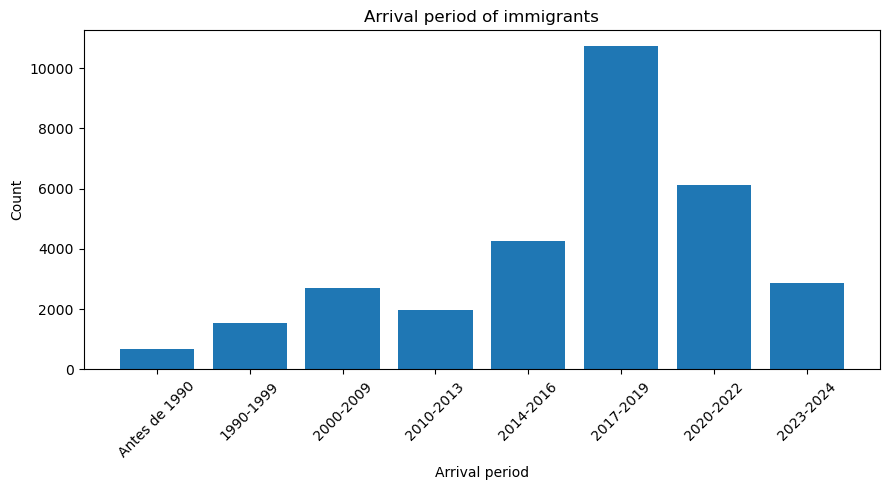

In [53]:
# Filtrar nacidos en el extranjero
arrival = df[
    (df["p25_lug_nacimiento_rec"] == 2) &
    (df["p26_llegada_periodo"] != -99) &
    (df["p26_llegada_periodo"].notna())
].copy()

# Contar periodos
arrival_dist = arrival["p26_llegada_periodo"].value_counts()

# Definir etiquetas
map_periodo = {
    8: "Antes de 1990",
    7: "1990-1999",
    6: "2000-2009",
    5: "2010-2013",
    4: "2014-2016",
    3: "2017-2019",
    2: "2020-2022",
    1: "2023-2024"
}

# Ordenar cronológicamente
orden = [8, 7, 6, 5, 4, 3, 2, 1]
arrival_dist = arrival_dist.reindex(orden)

# Asignar nombres
arrival_dist.index = arrival_dist.index.map(map_periodo)

# Graficar
plt.figure(figsize=(9, 5))
plt.bar(arrival_dist.index, arrival_dist.values)

plt.xticks(rotation=45)
plt.title("Arrival period of immigrants")
plt.xlabel("Arrival period")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

En este gráfico se observa que la llegada de inmigrantes a Maipú se concentra sobre todo en los años más recientes. El período con mayor cantidad de llegadas es 2017-2019, y aunque después los valores bajan, siguen siendo altos en comparación con los años anteriores. En cambio, antes de 2010 la cantidad de personas que llegó a la comuna era bastante menor. Por eso, los datos muestran que la inmigración en Maipú ha tomado más fuerza en los últimos años y que no se trata de algo que haya tenido el mismo peso durante todo el tiempo.

## Part 3: Spatial Visualization 

### 3.1 Choropleth map: population by comuna

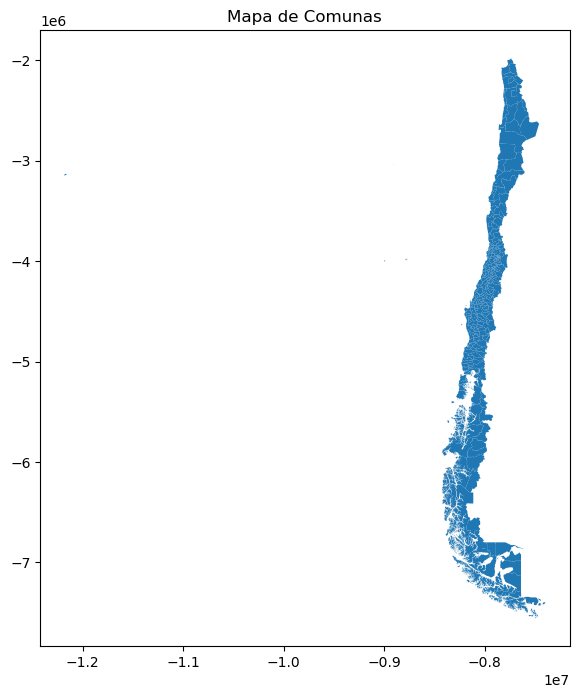

In [57]:
import geopandas as gpd

comunas = gpd.read_file("comunas.shp")

comunas.head()
comunas.columns

comunas.plot(figsize=(8,8))
plt.title("Mapa de Comunas")
plt.show()

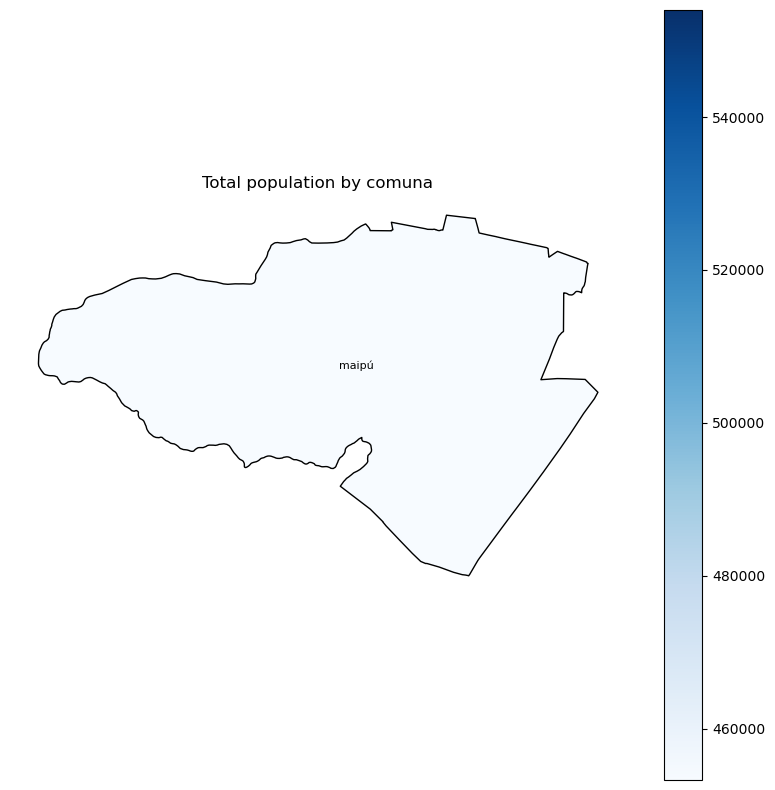

In [58]:
import os

# Leer shapefile
os.environ["SHAPE_RESTORE_SHX"] = "YES"
comunas = gpd.read_file("comunas.shp")

# Preparar tabla de población por comuna
map_pop = (
    df.groupby(["codigo_comuna", "nombre_comuna"])
    .size()
    .reset_index(name="pop_total")
)

# Asegurar mismo tipo de dato
comunas["cod_comuna"] = comunas["cod_comuna"].astype(int)
map_pop["codigo_comuna"] = map_pop["codigo_comuna"].astype(int)

# Merge shapefile + datos
mapa = comunas.merge(
    map_pop,
    left_on="cod_comuna",
    right_on="codigo_comuna",
    how="inner"
)

# Graficar mapa
fig, ax = plt.subplots(figsize=(8, 8))

mapa.plot(
    column="pop_total",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    ax=ax
)

# Etiquetas
for x, y, label in zip(
    mapa.geometry.centroid.x,
    mapa.geometry.centroid.y,
    mapa["nombre_comuna"]
):
    ax.text(x, y, label, fontsize=8, ha="center")

ax.set_title("Total population by comuna")
ax.set_axis_off()
plt.tight_layout()
plt.show()

En este mapa se observa la población total de Maipú, que supera las 500 mil personas. Como aquí solo se está analizando una comuna, no se pueden hacer comparaciones con otras, pero igual sirve para ubicar visualmente el territorio trabajado y mostrar que Maipú tiene una población alta.

### 3.2 Choropleth map: % foreign-born by comuna

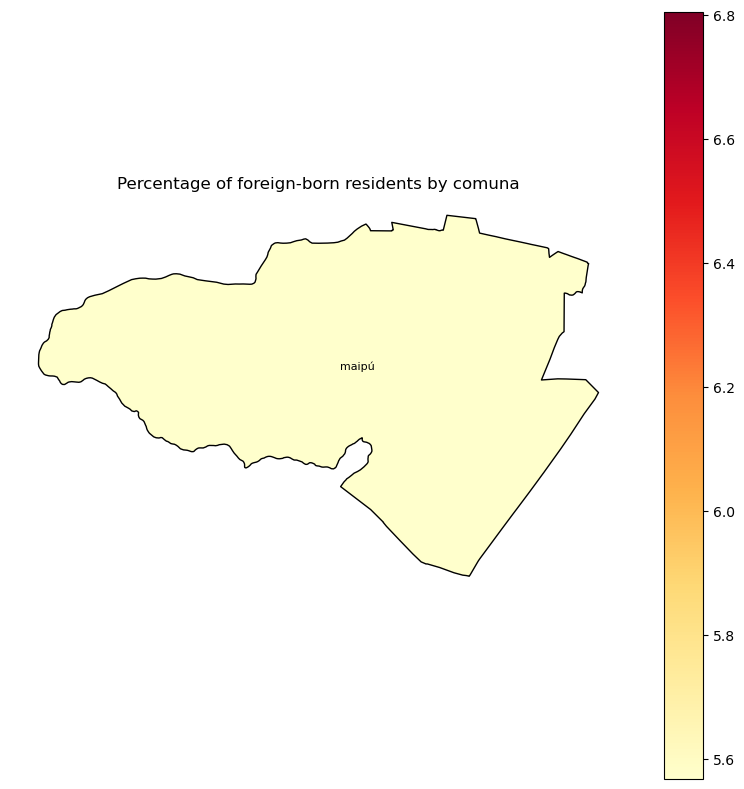

In [61]:
# Leer shapefile
os.environ["SHAPE_RESTORE_SHX"] = "YES"
comunas = gpd.read_file("comunas.shp")

# Filtrar valores válidos de lugar de nacimiento
foreign_map = df[
    (df["p25_lug_nacimiento_rec"] != -99)
].copy()

# Calcular población total y población nacida en el extranjero
map_foreign = (
    foreign_map
    .groupby(["codigo_comuna", "nombre_comuna"])
    .agg(
        pop_total=("id_persona", "count"),
        pop_foreign_born=("p25_lug_nacimiento_rec", lambda x: (x == 2).sum())
    )
    .reset_index()
)

# Calcular porcentaje
map_foreign["pct_foreign_born"] = (
    map_foreign["pop_foreign_born"] / map_foreign["pop_total"] * 100
)

# Asegurar mismo tipo de dato para el merge
comunas["cod_comuna"] = comunas["cod_comuna"].astype(int)
map_foreign["codigo_comuna"] = map_foreign["codigo_comuna"].astype(int)

# Unir shapefile con datos
mapa_foreign = comunas.merge(
    map_foreign,
    left_on="cod_comuna",
    right_on="codigo_comuna",
    how="inner"
)

# Graficar mapa
fig, ax = plt.subplots(figsize=(8, 8))

mapa_foreign.plot(
    column="pct_foreign_born",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

# Agregar etiquetas si son legibles
for x, y, label in zip(
    mapa_foreign.geometry.centroid.x,
    mapa_foreign.geometry.centroid.y,
    mapa_foreign["nombre_comuna"]
):
    ax.text(x, y, label, fontsize=8, ha="center")

ax.set_title("Percentage of foreign-born residents by comuna")
ax.set_axis_off()
plt.tight_layout()
plt.show()

En este mapa se observa que el porcentaje de población nacida en el extranjero en Maipú es cercano al 6%. Al igual que en el mapa anterior, aquí no se pueden hacer comparaciones con otras comunas porque solo se está trabajando con una. Aun así, el mapa sirve para mostrar de forma visual el peso que tiene esta población dentro de la comuna analizada.

## Part 4: Comuna-Level Summary Table

En este apartado se construye una tabla resumen a nivel de comuna que reúne los principales indicadores obtenidos a lo largo del trabajo. El objetivo es dejar en un solo lugar una síntesis general de los resultados para la comuna analizada.

In [65]:
# Definir códigos
chilean_code = 1
foreign_code = 2
employed_code = 1

# Crear función resumen
def build_summary(g):
    # Filtrar lugar de nacimiento válido
    g_birth = g[g["p25_lug_nacimiento_rec"] != -99].copy()

    # Calcular población
    pop_total = len(g_birth)
    pop_chilean = (g_birth["p25_lug_nacimiento_rec"] == chilean_code).sum()
    pop_foreign = (g_birth["p25_lug_nacimiento_rec"] == foreign_code).sum()

    # Calcular porcentaje extranjero
    pct_foreign = np.nan
    if pop_total > 0:
        pct_foreign = pop_foreign / pop_total * 100

    # Filtrar edades válidas
    g_age = g_birth[g_birth["edad"] != -99].copy()

    # Calcular mediana de edad
    median_age_chilean = g_age.loc[
        g_age["p25_lug_nacimiento_rec"] == chilean_code, "edad"
    ].median()

    median_age_foreign = g_age.loc[
        g_age["p25_lug_nacimiento_rec"] == foreign_code, "edad"
    ].median()

    # Filtrar escolaridad válida
    g_school = g_birth[
        (g_birth["edad"] != -99) &
        (g_birth["edad"] >= 25) &
        (g_birth["escolaridad"] != -99)
    ].copy()

    # Calcular escolaridad promedio
    mean_schooling_chilean = g_school.loc[
        g_school["p25_lug_nacimiento_rec"] == chilean_code, "escolaridad"
    ].mean()

    mean_schooling_foreign = g_school.loc[
        g_school["p25_lug_nacimiento_rec"] == foreign_code, "escolaridad"
    ].mean()

    # Filtrar empleo válido
    g_emp = g_birth[
        (g_birth["edad"] != -99) &
        (g_birth["edad"] >= 15) &
        (g_birth["edad"] <= 64) &
        (g_birth["sit_fuerza_trabajo"] != -99) &
        (g_birth["sit_fuerza_trabajo"].notna())
    ].copy()

    # Calcular tasa de empleo
    emp_rate_chilean = (
        g_emp.loc[
            g_emp["p25_lug_nacimiento_rec"] == chilean_code,
            "sit_fuerza_trabajo"
        ] == employed_code
    ).mean()

    emp_rate_foreign = (
        g_emp.loc[
            g_emp["p25_lug_nacimiento_rec"] == foreign_code,
            "sit_fuerza_trabajo"
        ] == employed_code
    ).mean()

    # Filtrar dependencia
    g_dep = g[g["edad"] != -99].copy()

    # Calcular grupos etarios
    dep_0_14 = ((g_dep["edad"] >= 0) & (g_dep["edad"] <= 14)).sum()
    dep_15_64 = ((g_dep["edad"] >= 15) & (g_dep["edad"] <= 64)).sum()
    dep_65_plus = (g_dep["edad"] >= 65).sum()

    # Calcular ratio de dependencia
    dependency_ratio = np.nan
    if dep_15_64 > 0:
        dependency_ratio = (dep_0_14 + dep_65_plus) / dep_15_64

    # Devolver resumen
    return pd.Series({
        "codigo_comuna": g["codigo_comuna"].iloc[0],
        "nombre_comuna": g["nombre_comuna"].iloc[0],
        "pop_total": pop_total,
        "pop_chilean": pop_chilean,
        "pop_foreign": pop_foreign,
        "pct_foreign": pct_foreign,
        "median_age_chilean": median_age_chilean,
        "median_age_foreign": median_age_foreign,
        "mean_schooling_chilean": mean_schooling_chilean,
        "mean_schooling_foreign": mean_schooling_foreign,
        "emp_rate_chilean": emp_rate_chilean,
        "emp_rate_foreign": emp_rate_foreign,
        "dependency_ratio": dependency_ratio
    })

# Construir tabla resumen
summary = (
    df.groupby("codigo_comuna")
    .apply(build_summary)
    .reset_index(drop=True)
)

# Redondear resultados
summary["pct_foreign"] = summary["pct_foreign"].round(2)
summary["median_age_chilean"] = summary["median_age_chilean"].round(2)
summary["median_age_foreign"] = summary["median_age_foreign"].round(2)
summary["mean_schooling_chilean"] = summary["mean_schooling_chilean"].round(2)
summary["mean_schooling_foreign"] = summary["mean_schooling_foreign"].round(2)
summary["emp_rate_chilean"] = summary["emp_rate_chilean"].round(4)
summary["emp_rate_foreign"] = summary["emp_rate_foreign"].round(4)
summary["dependency_ratio"] = summary["dependency_ratio"].round(4)

# Tabla
summary

,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13119,maipú,500600,469627,30973,6.19,38.0,34.0,12.64,12.98,0.6255,0.7351,0.4327


Y ahora para hacerlo más agradable a la vista realizaremos unos ajustes.

In [67]:
descriptions = {
    "codigo_comuna": "Numeric comuna code",
    "nombre_comuna": "Comuna name",
    "pop_total": "Total population",
    "pop_chilean": "Chilean-born population",
    "pop_foreign": "Foreign-born population",
    "pct_foreign": "% foreign-born",
    "median_age_chilean": "Median age, Chilean-born",
    "median_age_foreign": "Median age, foreign-born",
    "mean_schooling_chilean": "Mean years of schooling (age 25+), Chilean-born",
    "mean_schooling_foreign": "Mean years of schooling (age 25+), foreign-born",
    "emp_rate_chilean": "Employment rate (age 15-64), Chilean-born",
    "emp_rate_foreign": "Employment rate (age 15-64), foreign-born",
    "dependency_ratio": "Age dependency ratio (overall)"
}

summary_display = summary.iloc[0].reset_index()
summary_display.columns = ["Column", "Results"]

summary_display["Description"] = summary_display["Column"].map(descriptions)

summary_display = summary_display[["Column", "Description", "Results"]]

summary_display

,Column,Description,Results
0,codigo_comuna,Numeric comuna code,13119
1,nombre_comuna,Comuna name,maipú
2,pop_total,Total population,500600
3,pop_chilean,Chilean-born population,469627
4,pop_foreign,Foreign-born population,30973
5,pct_foreign,% foreign-born,6.19
6,median_age_chilean,"Median age, Chilean-born",38.0
7,median_age_foreign,"Median age, foreign-born",34.0
8,mean_schooling_chilean,"Mean years of schooling (age 25+), Chilean-born",12.64
9,mean_schooling_foreign,"Mean years of schooling (age 25+), foreign-born",12.98


En general, la tabla permite resumir de forma clara los principales resultados obtenidos para Maipú. Se observa que la mayor parte de la población nació en Chile, mientras que la población nacida en el extranjero representa una proporción menor, aunque con algunas diferencias en edad, escolaridad y empleo que ya se habían visto en los apartados anteriores.